# Walker constellation propagation

## Objectives

This example shows how to set up and propagate a satellite constellation using Tudat's multi-body propagation facilities. It demonstrates a **multi-shell architecture** in the style of Starlink: two Walker constellations at different altitudes and inclinations, propagated jointly under Earth's spherical-harmonic gravity field and third-body perturbations from the Sun and Moon.

The two shells are:

| Shell | Walker T/P/F | Altitude | Inclination | Purpose |
|---|---|---|---|---|
| **A** | 24 / 3 / 1 | 550 km | 53.0° | Mid-latitude coverage |
| **B** | 12 / 3 / 1 | 560 km | 97.6° | Sun-synchronous polar coverage |

Total: 36 satellites propagated over 24 hours.

**What this example shows:**
- Programmatic generation of Walker-constellation Keplerian elements
- Multi-shell concatenation (each shell built with the same generator, then combined)
- Multi-body environment + propagation setup at scale
- 3D visualization of orbits, ground tracks, and in-plane spacing
- The osculating-vs-mean-element drift that motivates stationkeeping in real constellations


## Import statements

First, let's import the needed python and tudat libraries, and let's load the standard SPICE kernels.


In [1]:
# Standard modules
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

# Tudatpy modules
from tudatpy import constants
from tudatpy import dynamics
from tudatpy.astro import element_conversion
from tudatpy.astro.time_representation import DateTime
from tudatpy.interface import spice
from tudatpy.dynamics import (
    environment_setup,
    propagation_setup,
    propagation,
    simulator,
)

# Load NAIF SPICE kernels (Earth, Sun, Moon ephemerides + rotation models)
spice.load_standard_kernels()

## Walker constellation parameters

Two shells defined as plain dictionaries. Each shell is itself a **Walker delta** constellation `T/P/F`, where:

- `T` is the total number of satellites in the shell,
- `P` is the number of orbital planes (so `T/P` satellites per plane),
- `F ∈ [0, P-1]` is the **phasing factor** (the relative angular offset between adjacent planes' satellites at the ascending node).

See the [Walker constellation summary on Wikipedia](https://en.wikipedia.org/wiki/Satellite_constellation#Walker_constellations) for an accessible derivation. We use Earth's mean radius from SPICE so the shell altitudes resolve to physically correct semi-major axes.


In [2]:
# Earth's mean radius from SPICE (meters)
EARTH_RADIUS = spice.get_average_radius("Earth")

# Shell A: Starlink-like mid-latitude shell
shell_A = {
    "name": "A",
    "T": 24,                    # total satellites in this shell
    "P": 3,                     # number of orbital planes
    "F": 1,                     # phasing factor (0..P-1)
    "altitude_m": 550.0e3,      # altitude above Earth's mean radius
    "sma_m": EARTH_RADIUS + 550.0e3,
    "eccentricity": 0.0,        # circular orbit
    "inclination_deg": 53.0,    # mid-latitude (Starlink Shell 1 nominal)
}

# Shell B: polar / sun-synchronous-like shell
shell_B = {
    "name": "B",
    "T": 12,
    "P": 3,
    "F": 1,
    "altitude_m": 560.0e3,
    "sma_m": EARTH_RADIUS + 560.0e3,
    "eccentricity": 0.0,
    "inclination_deg": 97.6,    # polar coverage; near sun-synchronous at this altitude
}

shells = [shell_A, shell_B]
total_sats = sum(s["T"] for s in shells)
print(f"Total satellites across all shells: {total_sats}")

Total satellites across all shells: 36


## Walker constellation generator

Let's add a utility function, named `generate_walker_kepler_elements`, that takes a Walker `T/P/F` specification and a shared orbital geometry (semi-major axis, eccentricity, inclination), and emits one Keplerian-element set per satellite. The formulas are from Walker (1984) — see the [Wikipedia summary](https://en.wikipedia.org/wiki/Satellite_constellation#Walker_constellations) for an accessible derivation.


In [3]:
def generate_walker_kepler_elements(
    T: int,
    P: int,
    F: int,
    sma_m: float,
    eccentricity: float,
    inclination_rad: float,
) -> list:
    """Generate Keplerian elements for a Walker constellation T/P/F.

    Args:
        T: total number of satellites
        P: number of orbital planes (must divide T evenly)
        F: phasing factor (integer in 0..P-1)
        sma_m: semi-major axis in metres (shared across all satellites in this shell)
        eccentricity: eccentricity (typically 0 for constellations)
        inclination_rad: inclination in radians (shared across all satellites)

    Returns:
        List of length T, each entry an np.ndarray shape (6,):
        [sma_m, eccentricity, inclination_rad, argument_of_periapsis_rad,
         RAAN_rad, true_anomaly_rad]
        — exactly the order Tudat's `element_conversion.keplerian_to_cartesian_elementwise` expects.
        Order in the list: all sats of plane 0 first (in true-anomaly order), then plane 1, then plane 2, ...

    See reference doc §2 for the math (RAAN per plane, true anomaly per sat-in-plane, phasing offset).
    """
    assert T % P == 0, "T must devide evenly"
    sats_per_plane = T // P
    result = []
    for k in range(P):
        raan_k = 2 * np.pi * k / P
        for j in range(sats_per_plane):
            true_anomaly_k = (2 * np.pi / sats_per_plane) * j + (2 * np.pi * F / T) * k
            true_anomaly_k %= 2 * np.pi
            kep = np.array([
                sma_m,
                eccentricity,
                inclination_rad,
                0.0,
                raan_k,
                true_anomaly_k,
            ])
            result.append(kep)
    return result

## Generate Keplerian elements for all satellites

Apply the generator to each shell and flatten into a single list of (kep_elements, satellite_name) tuples. Names follow the pattern `shell_{A,B}_p{plane}_s{sat_in_plane}` and are used as body identifiers throughout Tudat.

In [4]:
satellites = []  # list of dicts: {"name": str, "shell": str, "plane": int, "sat_in_plane": int, "kep": np.ndarray}

for shell in shells:
    kep_list = generate_walker_kepler_elements(
        T=shell["T"],
        P=shell["P"],
        F=shell["F"],
        sma_m=shell["sma_m"],
        eccentricity=shell["eccentricity"],
        inclination_rad=np.deg2rad(shell["inclination_deg"]),
    )
    sats_per_plane = shell["T"] // shell["P"]
    for idx, kep in enumerate(kep_list):
        plane = idx // sats_per_plane
        sat_in_plane = idx % sats_per_plane
        name = f"shell_{shell['name']}_p{plane}_s{sat_in_plane}"
        satellites.append({
            "name": name,
            "shell": shell["name"],
            "plane": plane,
            "sat_in_plane": sat_in_plane,
            "kep": kep,
        })

print(f"Generated Keplerian elements for {len(satellites)} satellites.")
print(f"First sat: {satellites[0]['name']} → kep = {satellites[0]['kep']}")

Generated Keplerian elements for 36 satellites.
First sat: shell_A_p0_s0 → kep = [6.92100837e+06 0.00000000e+00 9.25024504e-01 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


## Create environment and bodies

We will soon propagate the satellites we created under the gravitational influence of Sun, Earth and Moon. Let's then create the environment and bodies accordingly: Sun + Earth + Moon from SPICE defaults, plus one empty body per satellite. The empty-body pattern is the standard way to add custom spacecraft — mass and any other properties are set per-satellite after creation. For background see the [Tudat user guide on environment setup](https://docs.tudat.space/en/latest/_src_user_guide/state_propagation/environment_setup.html).


In [5]:
# Celestial bodies to load from SPICE defaults
bodies_to_create = ["Sun", "Earth", "Moon"]

global_frame_origin = "Earth"
global_frame_orientation = "J2000"

body_settings = environment_setup.get_default_body_settings(
    bodies_to_create,
    global_frame_origin,
    global_frame_orientation,
)

# Add an empty body for each satellite
SATELLITE_MASS_KG = 260.0  # Starlink v1.5 nominal mass; constant across constellation
for sat in satellites:
    body_settings.add_empty_settings(sat["name"])
    body_settings.get(sat["name"]).constant_mass = SATELLITE_MASS_KG

# Materialize the system
bodies = environment_setup.create_system_of_bodies(body_settings)
print(f"Created {len(bodies_to_create)} celestial bodies + {len(satellites)} satellites.")

Created 3 celestial bodies + 36 satellites.


## Acceleration settings

For LEO at ~550 km, the physically important forces are:

- **Earth gravity** — main term. We use a spherical-harmonic expansion to degree/order 8 (`spherical_harmonic_gravity(8, 8)`), which captures J2 (Earth's oblateness, dominant non-central term) plus higher-order zonal and tesseral terms.
- **Sun and Moon point-mass gravity** — third-body perturbations, small but non-trivial over a day.

To keep things simple, atmospheric drag is **not** included in this example. The same acceleration set applies to every satellite (no per-satellite differentiation in this scope). See the [tudatpy acceleration API](https://py.api.tudat.space/en/latest/acceleration.html) for the full menu of acceleration settings.


In [6]:
# Acceleration set applied to every satellite
accelerations_per_satellite = dict(
    Sun=[propagation_setup.acceleration.point_mass_gravity()],
    Earth=[propagation_setup.acceleration.spherical_harmonic_gravity(8, 8)],
    Moon=[propagation_setup.acceleration.point_mass_gravity()],
)

# Map each satellite name → acceleration spec
acceleration_settings = {sat["name"]: accelerations_per_satellite for sat in satellites}

# All satellites orbit Earth
bodies_to_propagate = [sat["name"] for sat in satellites]
central_bodies = ["Earth"] * len(satellites)

acceleration_models = propagation_setup.create_acceleration_models(
    bodies,
    acceleration_settings,
    bodies_to_propagate,
    central_bodies,
)

## Initial Cartesian states

Tudat propagates in Cartesian inertial coordinates (J2000), so the Keplerian sets must be converted. The result is a single flat vector of length `6 * N` where the first 6 entries are sat 0, the next 6 are sat 1, and so on — same order as `bodies_to_propagate`.

Cartesian conversion uses tudatpy's [`element_conversion.keplerian_to_cartesian_elementwise`](https://py.api.tudat.space/en/latest/element_conversion.html#tudatpy.astro.element_conversion.keplerian_to_cartesian_elementwise).


In [7]:
# Convert each Keplerian set to Cartesian, then concatenate into a single flat
# state vector of shape (6 * N_total_sats,) in the same order as `satellites`.

earth_mu = bodies.get("Earth").gravitational_parameter

initial_states_list = []
for sat in satellites:
    cartesian = element_conversion.keplerian_to_cartesian_elementwise(
        gravitational_parameter=earth_mu,
        semi_major_axis=sat["kep"][0],
        eccentricity=sat["kep"][1],
        inclination=sat["kep"][2],
        argument_of_periapsis=sat["kep"][3],
        longitude_of_ascending_node=sat["kep"][4],
        true_anomaly=sat["kep"][5],
    )
    sat["cartesian_initial"] = cartesian
    initial_states_list.append(cartesian)

initial_states = np.concatenate(initial_states_list)

## Dependent variables to save

We save the full Keplerian state for every satellite at every integration step. This is needed for the in-plane spacing analysis (post-processing §3) and is also useful for verifying the constellation is behaving as expected.

In [8]:
dependent_variables_to_save = [
    propagation_setup.dependent_variable.keplerian_state(sat["name"], "Earth")
    for sat in satellites
]

## Termination and integrator settings

Propagate over 24 hours (a full diurnal cycle for ground-track visualization). Use a variable-step Runge-Kutta-Fehlberg 7(8) integrator — a sensible default for LEO propagation.

In [9]:
# Simulation epochs
simulation_start_epoch = DateTime(2000, 1, 1).to_epoch()
simulation_end_epoch = simulation_start_epoch + constants.JULIAN_DAY  # 24 hours

# Time-based termination
termination_settings = propagation_setup.propagator.time_termination(simulation_end_epoch)

# Variable-step RKF 7(8)
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    initial_time_step=10.0,
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78,
    minimum_step_size=1.0,
    maximum_step_size=100.0,
    relative_error_tolerance=1.0e-10,
    absolute_error_tolerance=1.0e-10,
)

# Translational propagation settings
propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    initial_states,
    simulation_start_epoch,
    integrator_settings,
    termination_settings,
    output_variables=dependent_variables_to_save,
)

## Run the simulation

This is the actual numerical propagation. With 36 satellites over 24 hours under spherical-harmonic gravity, expect this to take several seconds — the spherical-harmonic expansion is the heaviest term.

In [10]:
dynamics_simulator = simulator.create_dynamics_simulator(bodies, propagator_settings)

state_history = dynamics_simulator.propagation_results.state_history
dependent_variable_history = dynamics_simulator.propagation_results.dependent_variable_history

epochs = np.array(list(state_history.keys()))
state_array = np.array(list(state_history.values()))         # shape (n_steps, 6 * N_sats)
dep_var_array = np.array(list(dependent_variable_history.values()))  # shape (n_steps, 6 * N_sats)

print(f"Propagated {len(epochs)} integration steps over "
      f"{(epochs[-1] - epochs[0]) / 3600:.1f} hours.")
print(f"State array shape: {state_array.shape}")

Propagated 908 integration steps over 24.0 hours.
State array shape: (908, 216)


## Post-processing 1 — 3D orbital geometry

Render all satellite orbits in inertial space, colored by shell (Shell A blue, Shell B red), with Earth as a reference sphere.

These positions are in J2000 inertial — see the [Tudat user guide on coordinate frames](https://docs.tudat.space/en/latest/_src_user_guide/state_propagation/transformation/frames.html) for the reference frame definitions.


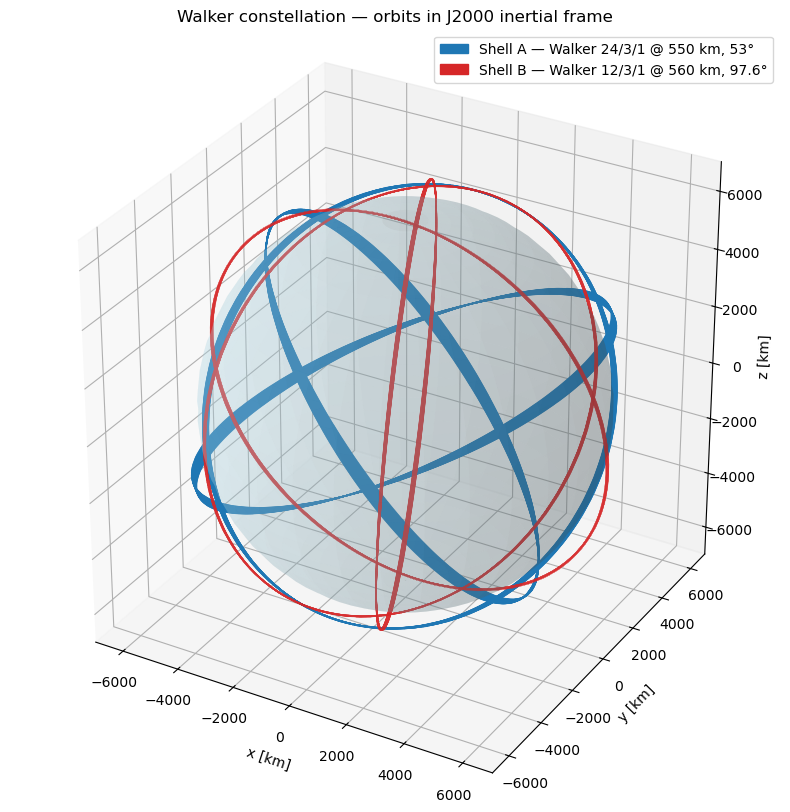

In [11]:
# 3D plot of all satellite orbits, colored by shell.
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

# Earth reference sphere
earth_r_km = EARTH_RADIUS / 1000.0
u = np.linspace(0, 2 * np.pi, 60)
v = np.linspace(0, np.pi, 30)
x_earth = earth_r_km * np.outer(np.cos(u), np.sin(v))
y_earth = earth_r_km * np.outer(np.sin(u), np.sin(v))
z_earth = earth_r_km * np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(x_earth, y_earth, z_earth, alpha=0.2, color="lightblue", linewidth=0)

# Per-satellite orbit, colored by shell
shell_color = {"A": "tab:blue", "B": "tab:red"}
for i, sat in enumerate(satellites):
    x = state_array[:, 6 * i + 0] / 1000.0
    y = state_array[:, 6 * i + 1] / 1000.0
    z = state_array[:, 6 * i + 2] / 1000.0
    ax.plot(x, y, z, color=shell_color[sat["shell"]], alpha=0.5, linewidth=0.8)

# Legend with one entry per shell
legend_handles = [
    mpatches.Patch(color=shell_color["A"], label="Shell A — Walker 24/3/1 @ 550 km, 53°"),
    mpatches.Patch(color=shell_color["B"], label="Shell B — Walker 12/3/1 @ 560 km, 97.6°"),
]
ax.legend(handles=legend_handles, loc="upper right")

ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.set_zlabel("z [km]")
ax.set_title("Walker constellation — orbits in J2000 inertial frame")

# Enforce equal axis limits so the Earth actually renders as a sphere — matplotlib
# auto-scales each 3D axis independently otherwise, which squashes the globe.
all_coords = np.concatenate([
    state_array[:, 6 * i + j] / 1000.0
    for i in range(len(satellites)) for j in range(3)
])
lim = max(np.max(np.abs(all_coords)), earth_r_km * 1.1)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)
ax.set_box_aspect([1, 1, 1])


## Post-processing 2 — ground tracks

Project sub-satellite points (the point on Earth's surface directly below each satellite) onto a 2D lat/lon map. This visualization makes the multi-shell architecture obvious: Shell A's 53°-inclined orbits trace mid-latitude bands, while Shell B's 97.6° polar orbits cover all latitudes including the poles.

**Important:** ground tracks need positions in the Earth-fixed (ECEF) frame, not J2000 inertial — the Earth is rotating beneath the orbit. The rotation comes from Tudat's Earth rotation model via
`bodies.get("Earth").rotation_model.inertial_to_body_fixed_rotation(epoch)`.


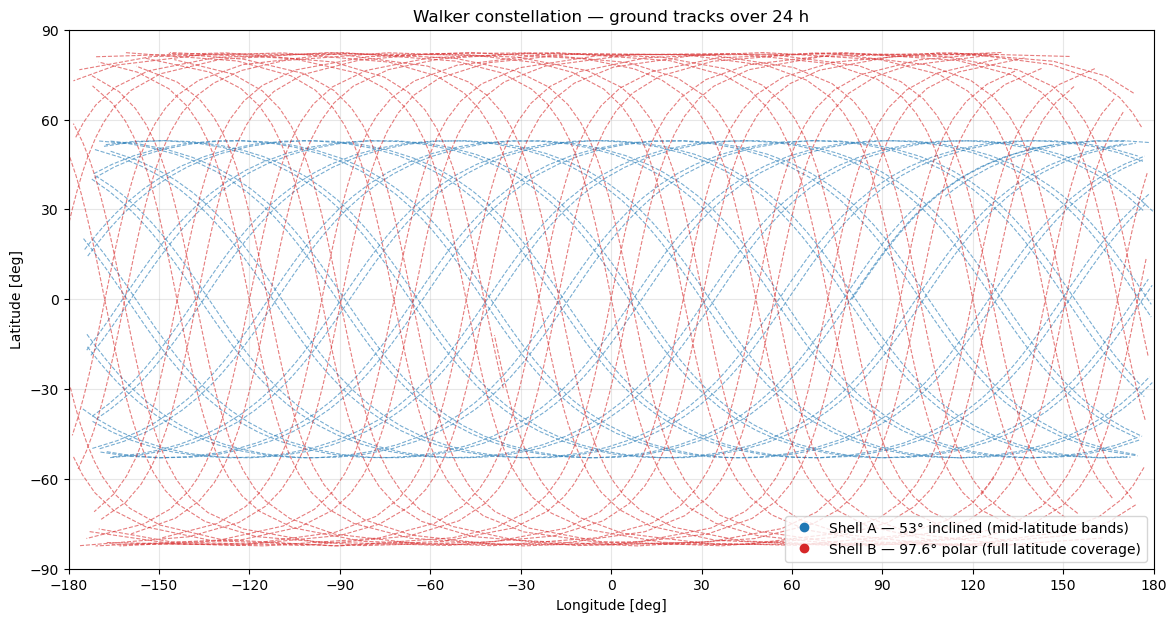

In [12]:
# Ground tracks: compute sub-satellite latitude/longitude via J2000 → ECEF rotation
import matplotlib.lines as mlines

earth_rotation_model = bodies.get("Earth").rotation_model

n_steps = len(epochs)
n_sats = len(satellites)
lats = np.zeros((n_steps, n_sats))
lons = np.zeros((n_steps, n_sats))

for t_idx, epoch in enumerate(epochs):
    R_j2000_to_ecef = earth_rotation_model.inertial_to_body_fixed_rotation(float(epoch))
    for i in range(n_sats):
        r_j2000 = state_array[t_idx, 6 * i : 6 * i + 3]
        r_ecef = R_j2000_to_ecef @ r_j2000
        r_norm = np.linalg.norm(r_ecef)
        lats[t_idx, i] = np.rad2deg(np.arcsin(r_ecef[2] / r_norm))
        lons[t_idx, i] = np.rad2deg(np.arctan2(r_ecef[1], r_ecef[0]))

# Plot two satellites per shell as dashed lines — keeps the figure readable
# while preserving each shell's characteristic ground-track shape. Indices
# 0, 1 are in Shell A (24 sats); 34, 35 are in Shell B (last two).
shell_color = {"A": "tab:blue", "B": "tab:red"}

def _mask_wrap(arr):
    out = arr.astype(float).copy()
    jumps = np.abs(np.diff(out, axis=0)) > 180.0
    out[1:][jumps] = np.nan
    return out

lons_plot = _mask_wrap(lons)

fig, ax = plt.subplots(figsize=(14, 7))
for i in (0, 1, 34, 35):
    ax.plot(lons_plot[:, i], lats[:, i],
            c=shell_color[satellites[i]["shell"]],
            linestyle="--", alpha=0.6, linewidth=0.8)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 30))
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("Walker constellation — ground tracks over 24 h")
ax.grid(True, alpha=0.3)

# Proxy legend (scatter does not auto-legend nicely)
legend_handles = [
    mlines.Line2D([], [], color=shell_color["A"], marker="o", linestyle="None",
                  label="Shell A — 53° inclined (mid-latitude bands)"),
    mlines.Line2D([], [], color=shell_color["B"], marker="o", linestyle="None",
                  label="Shell B — 97.6° polar (full latitude coverage)"),
]
ax.legend(handles=legend_handles, loc="lower right")

## Post-processing 3 — in-plane spacing analysis and it's drift

Plot the angular separation between adjacent satellites in Shell A, plane 0. Initially these 8 satellites are spaced exactly **45°** apart (`= 360° / (T/P) = 360° / 8`). We measure spacing directly from position vectors via `arccos(r̂₁ · r̂₂)` — this is singularity-free for circular orbits where the Keplerian true anomaly is degenerate.

**What we observe:** the spacing is not staying at 45°. It drifts by ~7° over 24 hours, with an alternating pattern by satellite-pair index (adjacent pairs split into two bundles, one drifting up to ~52°, the other down to ~38°). 

### Why

We initialised all 8 satellites with **identical osculating** Keplerian elements (same `a`, `e`, `i`, `Ω`, `ω`) but different `ν`. Tudat then faithfully integrates Newton + J2 in Cartesian coordinates.

And since the **osculating** elements differ from the **mean** (Brouwer-Lyddane) elements by short-period oscillations, the amplitude of which depends on the instantaneous phase of the satellite, even though all eight satellites have identical osculating semi-major axes of `a = 6921 km`, their *mean* semi-major axes differ slightly by an amount dependent on phase:

$$
a_{\text{mean}}(\nu) \;=\; a_{\text{osc}} \;-\; \delta a_{J_2}(\nu, \omega, i)
$$

Different mean `a` ⇒ different mean motion ⇒ slow secular drift in along-track position between satellites. The order-of-magnitude derivation:

- The short-period $J_2$ contribution to the semi-major axis scales as $\delta a / a \sim J_2 (R_\oplus / a)^2$. For LEO at $a \approx R_\oplus + 550\,\text{km}$ with $J_2 \approx 1.083 \times 10^{-3}$, this gives $\delta a / a \sim 10^{-3}$ (the leading factor swallows the $(R_\oplus/a)^2 \approx 0.85$).
- From Kepler's third law $n \propto a^{-3/2}$, hence $\delta n / n = -\tfrac{3}{2}\,\delta a / a \sim 10^{-3}$.
- Over 15 orbits (24 h at a ~95-min period), the cumulative along-track phase difference between two sats whose mean $a$ differ by this amount is $\sim 15 \times 10^{-3} \times 360° \approx 5\text{--}7°$ — which is consistent with what we see in the plot.

The **alternating two-bundle pattern** comes from the 2-per-orbit phase dependence of $\delta a_{J_2}(\nu)$: satellites 180° apart in true anomaly see identical short-period offsets, producing the 4-fold pair-index symmetry visible in the plot.

This is the dominant cause: replacing the full `spherical_harmonic_gravity(8, 8)` + Sun + Moon set-up with **only J2** (no tesserals, no 3rd-body) gives essentially the same drift (within 0.2°). Higher-order zonals, tesserals, and 3rd-body perturbations contribute small additional effects on top of the J2-driven mean-element separation. 

### How to fix

To preserve Walker geometry *exactly* in simulation, you would invert the Brouwer-Lyddane mean-to-osculating transformation: choose osculating initial conditions per satellite such that the **mean** elements are uniform across the constellation. This is left out of scope of this example.

**Further reading:**
- Curtis, *Orbital Mechanics for Engineering Students* (4th ed.), Ch. 10 — Orbital perturbations
- Vallado, *Fundamentals of Astrodynamics and Applications* (4th ed.), §9.3 — Special perturbations
- Brouwer (1959), "Solution of the problem of artificial satellite theory without drag", *Astron. J.* 64, 378

Shell A plane 0: 8 sats, ideal spacing 45.0°
Spacing range over 24 h: min=37.876°, max=52.179°, std=4.1132° (ideal 45.0°)


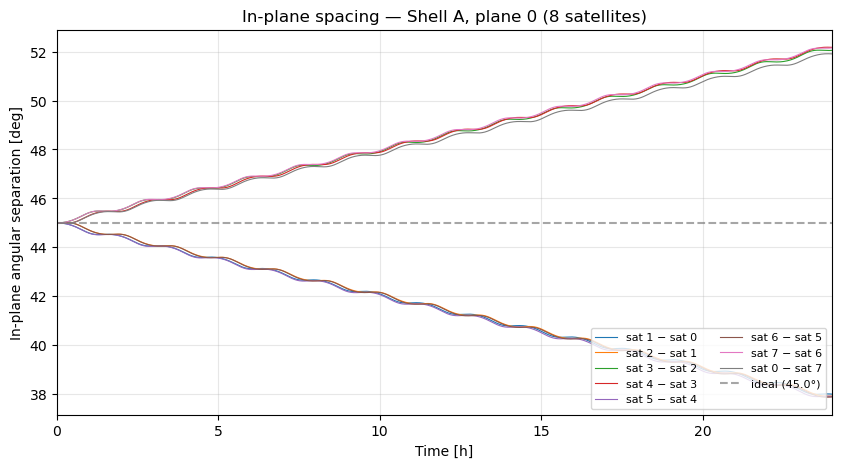

In [13]:
# In-plane angular spacing for Shell A, plane 0 — verifies Walker geometry is preserved during propagation
target_shell, target_plane = "A", 0

target_indices = [
    i for i, s in enumerate(satellites)
    if s["shell"] == target_shell and s["plane"] == target_plane
]
n_target = len(target_indices)

shell_config = next(s for s in shells if s["name"] == target_shell)
expected = shell_config["T"] // shell_config["P"]
assert n_target == expected, f"expected {expected} sats, got {n_target}"
ideal_spacing_deg = 360.0 / n_target
print(f"Shell {target_shell} plane {target_plane}: {n_target} sats, ideal spacing {ideal_spacing_deg:.1f}°")

# Extract position vectors for the target sats: shape (n_steps, n_target, 3)
positions = np.zeros((len(epochs), n_target, 3))
for j, sat_idx in enumerate(target_indices):
    positions[:, j, :] = state_array[:, 6 * sat_idx : 6 * sat_idx + 3]

# Pairwise adjacent angular separations via arccos(r̂₁ · r̂₂)
# (singularity-free; works whether the underlying tЧасть пар спутников (верхний пучок) непрерывно увеличивает дистанцию между собой (угол растет к 52°), а другая часть (нижний пучок) — догоняет друг друга (угол падает к 38°).rue anomaly is well-defined or not)
hours = (epochs - epochs[0]) / 3600.0
pairs = [(j, (j + 1) % n_target) for j in range(n_target)]

fig, ax = plt.subplots(figsize=(10, 5))
for j_start, j_end in pairs:
    r1 = positions[:, j_start, :]
    r2 = positions[:, j_end, :]
    cos_theta = np.einsum("ij,ij->i", r1, r2) / (
        np.linalg.norm(r1, axis=1) * np.linalg.norm(r2, axis=1)
    )
    cos_theta = np.clip(cos_theta, -1.0, 1.0)  # protect arccos from numerical >1 or <-1
    angle_deg = np.rad2deg(np.arccos(cos_theta))
    ax.plot(hours, angle_deg, label=f"sat {j_end} − sat {j_start}", linewidth=0.8)

ax.axhline(ideal_spacing_deg, color="gray", linestyle="--", alpha=0.7,
           label=f"ideal ({ideal_spacing_deg:.1f}°)")
ax.set_xlabel("Time [h]")
ax.set_ylabel("In-plane angular separation [deg]")
ax.set_title(f"In-plane spacing — Shell {target_shell}, plane {target_plane} "
             f"({n_target} satellites)")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.set_xlim(0, hours[-1])

# Diagnostic: print min/max spacing across all pairs, all times
all_spacings = []
for j_start, j_end in pairs:
    r1 = positions[:, j_start, :]
    r2 = positions[:, j_end, :]
    cos_theta = np.clip(
        np.einsum("ij,ij->i", r1, r2) / (np.linalg.norm(r1, axis=1) * np.linalg.norm(r2, axis=1)),
        -1.0, 1.0,
    )
    all_spacings.append(np.rad2deg(np.arccos(cos_theta)))
all_spacings = np.concatenate(all_spacings)
print(f"Spacing range over 24 h: min={all_spacings.min():.3f}°, max={all_spacings.max():.3f}°, "
      f"std={all_spacings.std():.4f}° (ideal {ideal_spacing_deg:.1f}°)")

## Show all figures

Required to render the figures in jupyter.

In [14]:
plt.show()

## Where to go from here

This example deliberately keeps scope tight, so that the focus stays on the constellation-setup pattern itself. There are several natural directions in which to extend it, each substantial enough to make a good follow-up notebook on its own.

The first is **drag and atmosphere modelling**: at 550 km the atmosphere still has a measurable effect on the orbit, and adding per-satellite aerodynamic coefficients together with an atmosphere model lets us watch the constellation gradually decay — and lets us reason about the stationkeeping budget required to maintain it. **Solar radiation pressure** sits in the same family: smaller in magnitude, but real, and the per-satellite SRP-coefficient pattern is the same.

A second direction is **inter-satellite-link geometry**: compute pairwise line-of-sight visibility (optionally accounting for Earth occultation) over time. That is the natural step toward any constellation-tasking or relay study. Close to that is **ground-coverage analysis**: for a chosen set of ground points, compute satellite visibility windows and aggregate them across shells to quantify the coverage gain of adding a polar shell.

Finally, the J2-driven drift discussed above motivates **maneuver planning**: periodic stationkeeping burns to compensate the secular along-track separation, or coordinated burns for constellation reconfiguration. Both fit on top of the same Walker generator presented here.
